In [1]:
# =============================================================================
# Task 3: Cross-Country Comparison & Climate Vulnerability Ranking
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For statistical testing (ANOVA/Kruskal-Wallis)
import os

# Set display options for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

print("--- Starting Cross-Country Comparison & Vulnerability Ranking ---")

--- Starting Cross-Country Comparison & Vulnerability Ranking ---


## Part 1: Data Loading and Concatenation

*   **Objective:** Load all cleaned datasets and combine them into a single DataFrame for comparative analysis.

In [2]:
# List of countries and their cleaned data paths
countries = ['Ethiopia', 'Kenya', 'Sudan', 'Tanzania', 'Nigeria']
data_frames = []

# The cleaned CSVs are in '../data/' relative to the 'notebooks/' directory
data_dir = '../data'

print(f"\nLoading cleaned data for {', '.join(countries)}...")
for country in countries:
    file_path = os.path.join(data_dir, f'{country.lower()}_clean.csv')
    try:
        df_country = pd.read_csv(file_path, parse_dates=['Date']) # Ensure 'Date' column is parsed as datetime
        data_frames.append(df_country)
        print(f"  Loaded {country}: {len(df_country)} rows.")
    except FileNotFoundError:
        print(f"  ERROR: Cleaned data file not found for {country} at {file_path}. Please ensure Task 2 is complete for all countries.")
        raise

# Concatenate all DataFrames into a single one
all_countries_df = pd.concat(data_frames, ignore_index=True)

print("\n--- Consolidated DataFrame Info ---")
all_countries_df.info()
print("\n--- Consolidated DataFrame Head ---")
print(all_countries_df.head())
print("\n--- Value counts of 'Country' to confirm all loaded ---")
print(all_countries_df['Country'].value_counts())


Loading cleaned data for Ethiopia, Kenya, Sudan, Tanzania, Nigeria...
  Loaded Ethiopia: 4108 rows.
  Loaded Kenya: 4108 rows.
  Loaded Sudan: 4108 rows.
  Loaded Tanzania: 4108 rows.
  Loaded Nigeria: 4108 rows.

--- Consolidated DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20540 entries, 0 to 20539
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         20540 non-null  int64         
 1   DOY          20540 non-null  int64         
 2   T2M          20540 non-null  float64       
 3   T2M_MAX      20540 non-null  float64       
 4   T2M_MIN      20540 non-null  float64       
 5   T2M_RANGE    20540 non-null  float64       
 6   PRECTOTCORR  20540 non-null  float64       
 7   RH2M         20540 non-null  float64       
 8   WS2M         20540 non-null  float64       
 9   WS2M_MAX     20540 non-null  float64       
 10  PS           20540 non-null  float64       
 11

## Part 2: Temperature Trend Comparison

*   **Objective:** Visualize monthly average temperatures across all countries and present a summary table of key temperature statistics.


--- Plotting Monthly Average T2M for All Countries ---


C:\Users\HP\AppData\Local\Temp\ipykernel_21488\1473196554.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_t2m_all = all_countries_df_indexed.groupby('Country')['T2M'].resample('M').mean().reset_index()


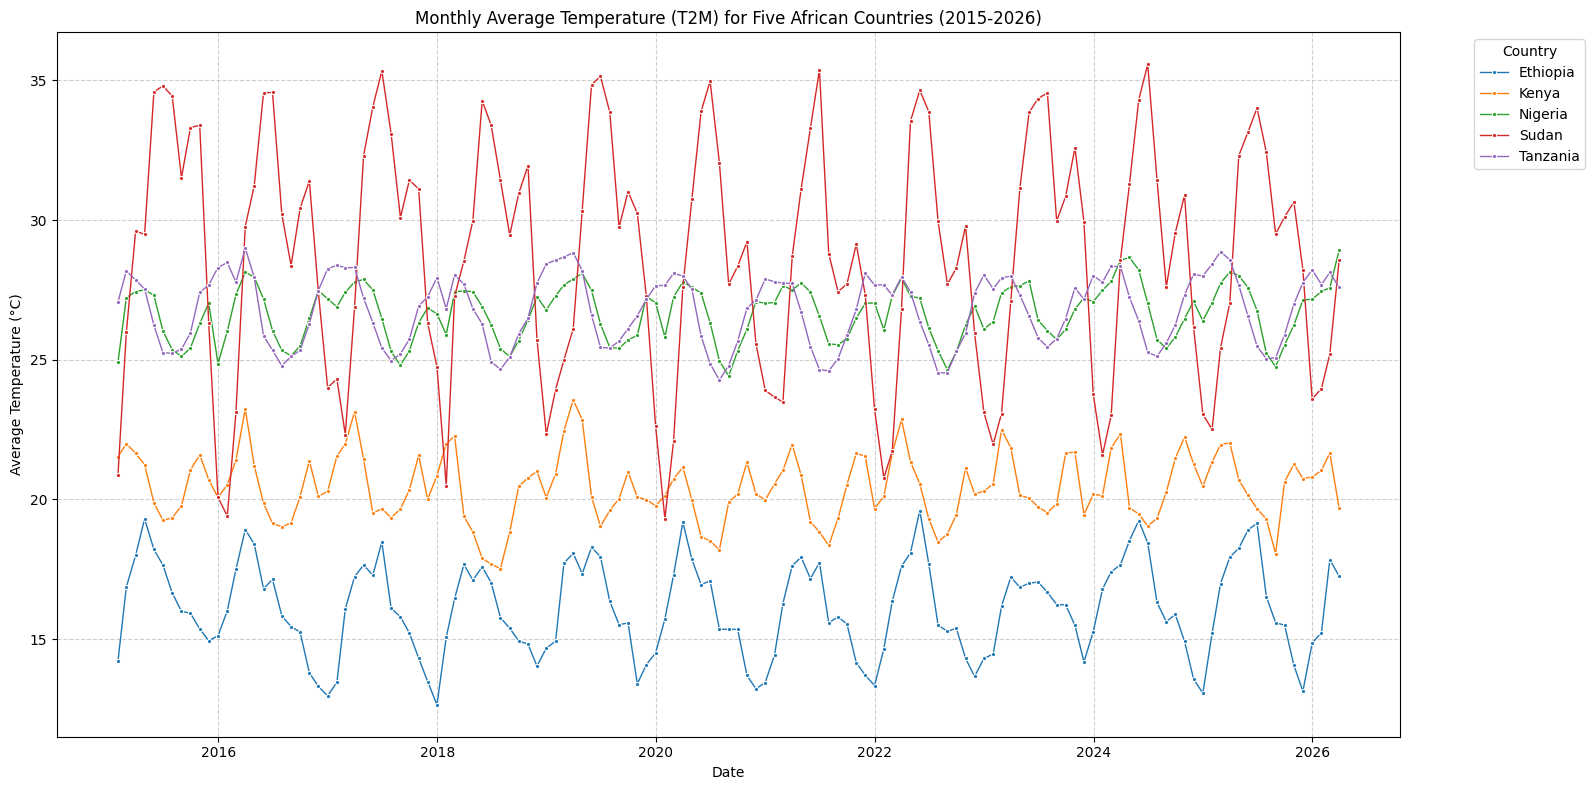

In [3]:
print("\n--- Plotting Monthly Average T2M for All Countries ---")

# Ensure 'Date' is the index for resampling, then reset to make it a column for plotting
all_countries_df_indexed = all_countries_df.set_index('Date')
monthly_avg_t2m_all = all_countries_df_indexed.groupby('Country')['T2M'].resample('M').mean().reset_index()

plt.figure(figsize=(16, 8))
sns.lineplot(data=monthly_avg_t2m_all, x='Date', y='T2M', hue='Country', marker='o', markersize=3, linewidth=1)
plt.title('Monthly Average Temperature (T2M) for Five African Countries (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [4]:
print("\n--- Summary Table: Mean, Median, Std Dev of T2M Across Countries ---")

t2m_summary = all_countries_df.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).reset_index()
t2m_summary.columns = ['Country', 'Mean T2M (°C)', 'Median T2M (°C)', 'Std Dev T2M (°C)']
print(t2m_summary)


--- Summary Table: Mean, Median, Std Dev of T2M Across Countries ---
    Country  Mean T2M (°C)  Median T2M (°C)  Std Dev T2M (°C)
0  Ethiopia          16.07            16.04              1.90
1     Kenya          20.43            20.36              1.44
2   Nigeria          26.66            26.82              1.12
3     Sudan          28.76            29.16              4.68
4  Tanzania          26.80            26.99              1.33


## Part 3: Precipitation Variability Comparison

*   **Objective:** Visualize precipitation distribution and variability across countries using boxplots, and summarize key precipitation statistics.


--- Boxplots of PRECTOTCORR for All Countries ---


C:\Users\HP\AppData\Local\Temp\ipykernel_21488\2831759630.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_countries_df, x='Country', y='PRECTOTCORR', palette='viridis')


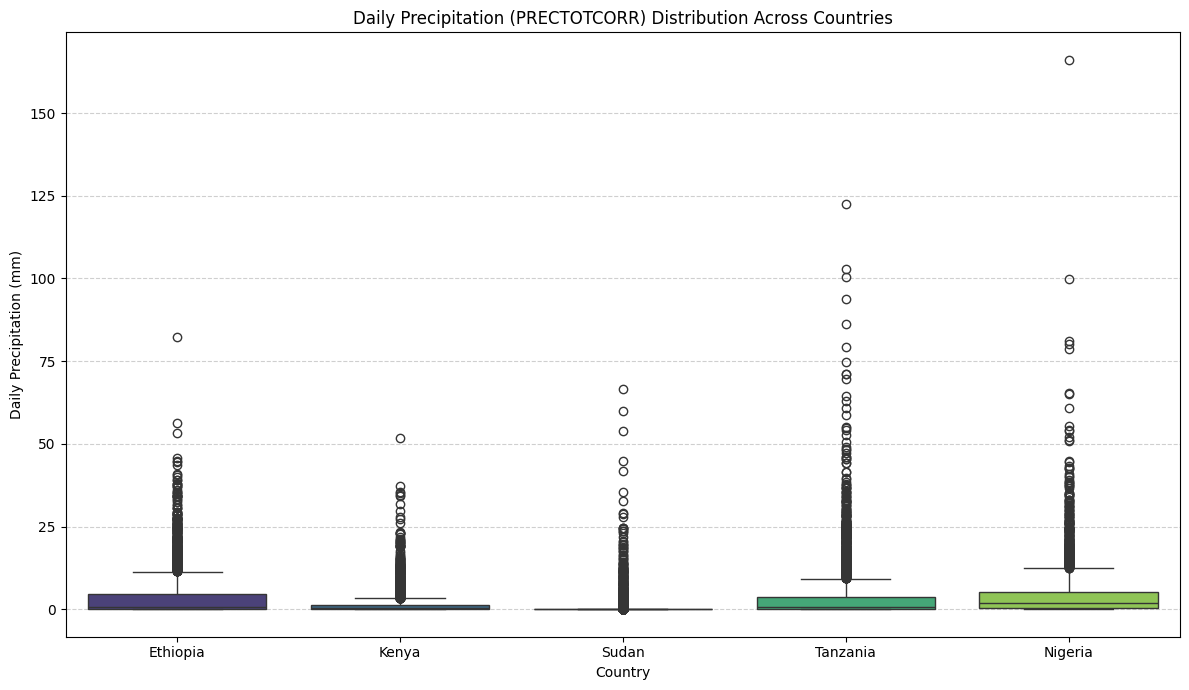

In [6]:
print("\n--- Boxplots of PRECTOTCORR for All Countries ---")

# Filter out 0 precipitation for better visualization of variability when it rains,
# or keep if 0s are crucial to show frequency of dry days.
# For variability, often non-zero values are of interest.
# Let's keep 0s for a full distribution representation.

plt.figure(figsize=(12, 7))
sns.boxplot(data=all_countries_df, x='Country', y='PRECTOTCORR', palette='viridis')
plt.title('Daily Precipitation (PRECTOTCORR) Distribution Across Countries')
plt.xlabel('Country')
plt.ylabel('Daily Precipitation (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [7]:
print("\n--- Summary Table: Mean, Median, Std Dev of PRECTOTCORR Across Countries ---")

prec_summary = all_countries_df.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).reset_index()
prec_summary.columns = ['Country', 'Mean PRECTOTCORR (mm)', 'Median PRECTOTCORR (mm)', 'Std Dev PRECTOTCORR (mm)']
print(prec_summary)


--- Summary Table: Mean, Median, Std Dev of PRECTOTCORR Across Countries ---
    Country  Mean PRECTOTCORR (mm)  Median PRECTOTCORR (mm)  Std Dev PRECTOTCORR (mm)
0  Ethiopia                   3.63                     0.82                      6.29
1     Kenya                   1.47                     0.38                      3.18
2   Nigeria                   4.21                     1.84                      7.27
3     Sudan                   0.64                     0.00                      3.06
4  Tanzania                   3.74                     0.64                      8.00


## Part 4: Extreme Event Frequency

*   **Objective:** Quantify and visualize the frequency of extreme heat days and consecutive dry days across countries.


--- Extreme Event Frequency: Extreme Heat Days (T2M_MAX > 35°C) ---

Average Annual Extreme Heat Days (>35°C):
  Country  AvgAnnualExtremeHeatDays
0   Sudan                    224.50


C:\Users\HP\AppData\Local\Temp\ipykernel_21488\1191789303.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_annual_heat_days, x='Country', y='AvgAnnualExtremeHeatDays', palette='Reds_d')


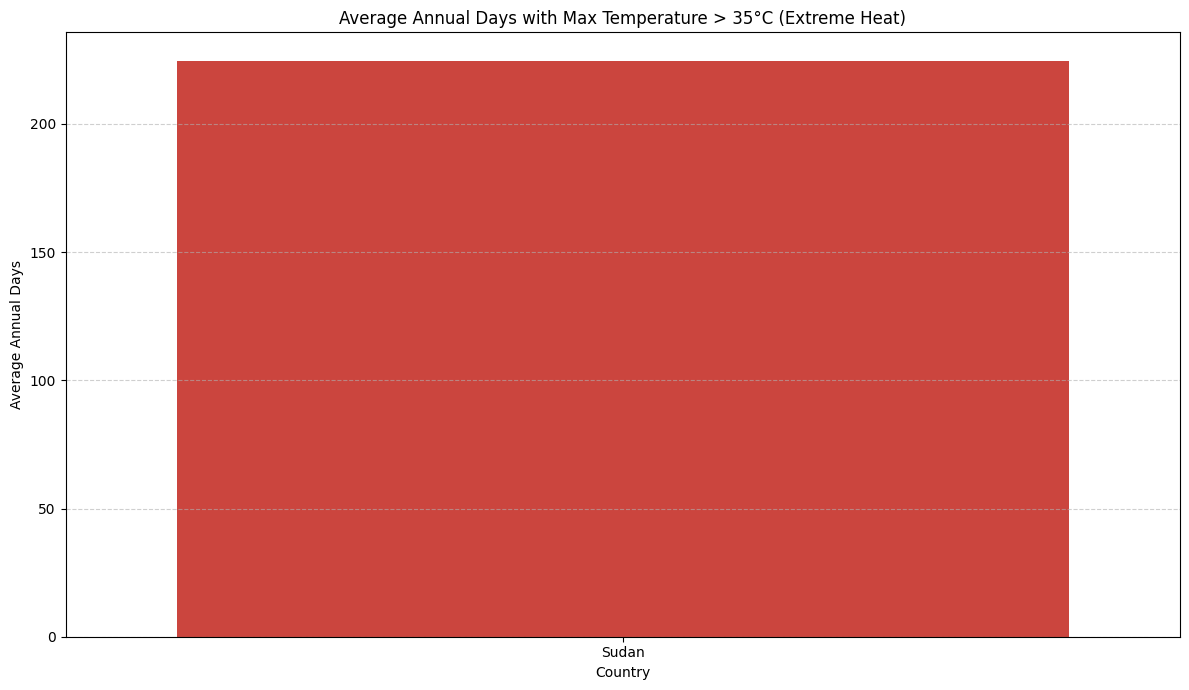

In [8]:
print("\n--- Extreme Event Frequency: Extreme Heat Days (T2M_MAX > 35°C) ---")

# Count days where T2M_MAX exceeds 35°C per year per country
extreme_heat_days = all_countries_df[all_countries_df['T2M_MAX'] > 35] \
                                 .groupby(['Country', all_countries_df['Date'].dt.year]) \
                                 .size().reset_index(name='ExtremeHeatDays')
extreme_heat_days.rename(columns={'Date': 'Year'}, inplace=True)

# Calculate average annual extreme heat days
avg_annual_heat_days = extreme_heat_days.groupby('Country')['ExtremeHeatDays'].mean().reset_index()
avg_annual_heat_days.columns = ['Country', 'AvgAnnualExtremeHeatDays']
print("\nAverage Annual Extreme Heat Days (>35°C):")
print(avg_annual_heat_days.sort_values(by='AvgAnnualExtremeHeatDays', ascending=False))

# Bar chart visualization
plt.figure(figsize=(12, 7))
sns.barplot(data=avg_annual_heat_days, x='Country', y='AvgAnnualExtremeHeatDays', palette='Reds_d')
plt.title('Average Annual Days with Max Temperature > 35°C (Extreme Heat)')
plt.xlabel('Country')
plt.ylabel('Average Annual Days')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


--- Extreme Event Frequency: Consecutive Dry Days (PRECTOTCORR < 1 mm) ---

Average Annual Max Consecutive Dry Days (<1mm):
    Country  AvgAnnualMaxConsecutiveDryDays
3     Sudan                          142.75
1     Kenya                           41.08
4  Tanzania                           40.25
0  Ethiopia                           37.92
2   Nigeria                           35.83


C:\Users\HP\AppData\Local\Temp\ipykernel_21488\4095324369.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_max_consecutive_dry_days).reset_index(name='MaxConsecutiveDryDays')
C:\Users\HP\AppData\Local\Temp\ipykernel_21488\4095324369.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_annual_dry_days, x='Country', y='AvgAnnualMaxConsecutiveDryDays', palette='Blues_d')


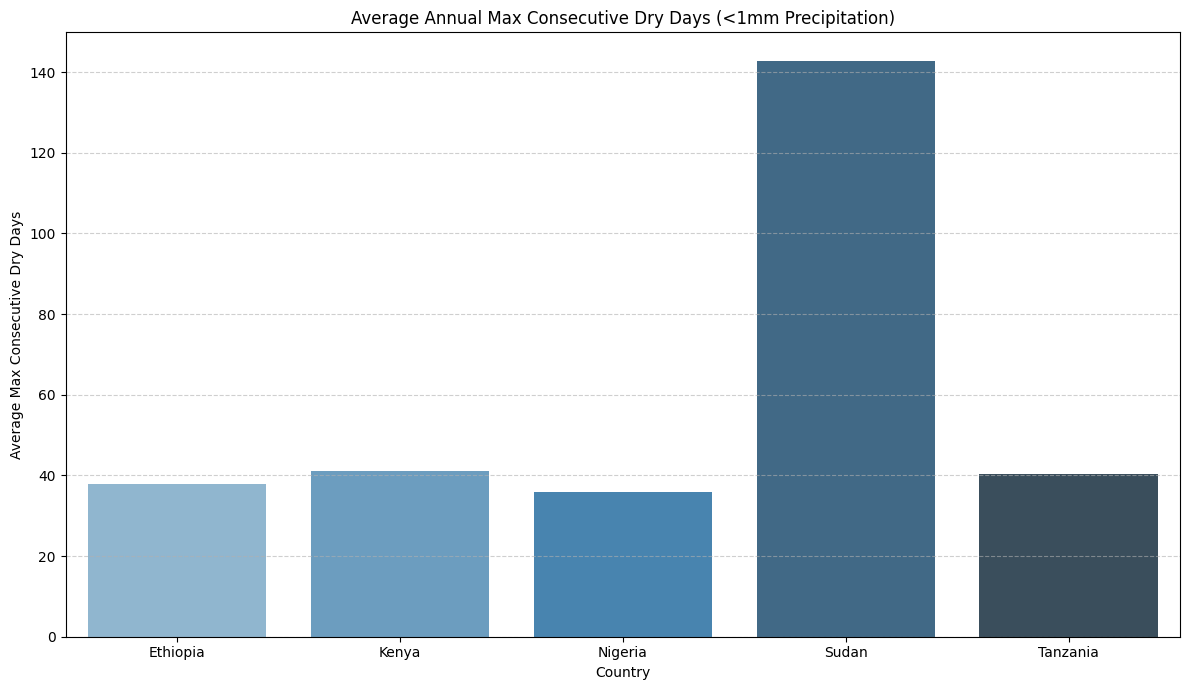

In [9]:
print("\n--- Extreme Event Frequency: Consecutive Dry Days (PRECTOTCORR < 1 mm) ---")

# Define dry day threshold
DRY_DAY_THRESHOLD = 1 # mm

# Function to calculate max consecutive dry days for each country-year
def get_max_consecutive_dry_days(group):
    # Sort by date just in case
    group = group.sort_values('Date')
    # Create a boolean series: True if dry, False if not
    is_dry = group['PRECTOTCORR'] < DRY_DAY_THRESHOLD
    # Identify start of dry streaks
    dry_streaks = (is_dry != is_dry.shift()).cumsum()
    # Count consecutive dry days
    consecutive_dry_days = is_dry.groupby(dry_streaks).cumsum()
    # Filter for only dry periods and get the max streak
    if is_dry.any(): # Only consider if there's at least one dry day
        return consecutive_dry_days[is_dry].max()
    return 0

# Group by country and year, then apply the function
all_countries_df['Year'] = all_countries_df['Date'].dt.year
max_consecutive_dry_days_per_year = all_countries_df.groupby(['Country', 'Year']) \
                                                    .apply(get_max_consecutive_dry_days).reset_index(name='MaxConsecutiveDryDays')

# Calculate average max consecutive dry days annually
avg_annual_dry_days = max_consecutive_dry_days_per_year.groupby('Country')['MaxConsecutiveDryDays'].mean().reset_index()
avg_annual_dry_days.columns = ['Country', 'AvgAnnualMaxConsecutiveDryDays']
print("\nAverage Annual Max Consecutive Dry Days (<1mm):")
print(avg_annual_dry_days.sort_values(by='AvgAnnualMaxConsecutiveDryDays', ascending=False))

# Bar chart visualization
plt.figure(figsize=(12, 7))
sns.barplot(data=avg_annual_dry_days, x='Country', y='AvgAnnualMaxConsecutiveDryDays', palette='Blues_d')
plt.title('Average Annual Max Consecutive Dry Days (<1mm Precipitation)')
plt.xlabel('Country')
plt.ylabel('Average Max Consecutive Dry Days')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Clean up the temporary 'Year' column
all_countries_df.drop(columns=['Year'], inplace=True)

## Part 5: Statistical Testing (Optional but Recommended)

*   **Objective:** Assess if differences in mean `T2M` values across countries are statistically significant.

In [11]:
print("\n--- Statistical Testing: One-way ANOVA on T2M ---")

# Prepare data for ANOVA: list of T2M arrays for each country
t2m_by_country = [all_countries_df['T2M'][all_countries_df['Country'] == country].dropna() for country in countries]

# Perform One-way ANOVA
# Assumes normality and equal variances. If not met, Kruskal-Wallis is non-parametric alternative.
# For this challenge, ANOVA is a good starting point.
f_statistic, p_value = stats.f_oneway(*t2m_by_country)

print(f"One-way ANOVA F-statistic for T2M across countries: {f_statistic:.2f}")
print(f"One-way ANOVA p-value for T2M across countries: {p_value:.3e}")




--- Statistical Testing: One-way ANOVA on T2M ---
One-way ANOVA F-statistic for T2M across countries: 18938.75
One-way ANOVA p-value for T2M across countries: 0.000e+00


## Part 6: Vulnerability Ranking & Key Observations

*   **Objective:** Synthesize findings into a country vulnerability ranking and articulate key observations for Ethiopia's COP32 position paper.